# Figure 2 - Minipools panels
Mathieu Bourdenx - UCL/UKDRI - 2026

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import palantir
import gseapy as gp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

from scipy.stats import pearsonr, false_discovery_control
from tqdm.notebook import tqdm
import PyComplexHeatmap as pch
from adjustText import adjust_text

# Housekeeping

In [2]:
raw_data_path = '../data/raw_data'
processed_data_path = '../data/processed_data'
results_path = '../results'

figure_path = '../figures/figure2'
os.makedirs(figure_path, exist_ok=True)

In [3]:
# Group colors
group_colors = {'pos': '#FEC200', 
         'neg': '#0C6F9F'}

In [33]:
# FDR threshold
fdr_thresh = 0.05

# Load data

In [4]:
pool = sc.read_h5ad(os.path.join(processed_data_path, 'pool_processed.h5ad'))

# Pseudotime

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:438: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


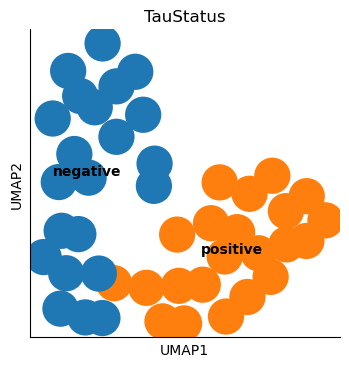

In [5]:
# UMAP
sc.tl.pca(pool,use_highly_variable=False)
sc.pp.neighbors(pool, n_neighbors=10, )
sc.tl.umap(pool)

# UMAP colored by tau status
sc.pl.umap(pool, color=['TauStatus'], legend_loc='on data')
plt.show()

In [6]:
# Palantir diffusion map
palantir.utils.run_diffusion_maps(pool, n_components=5, knn=5)

{'T': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 278 stored elements and shape (44, 44)>,
 'EigenVectors':            0         1         2         3         4
 0  -0.150756  0.110197 -0.014405  0.201561  0.167718
 1  -0.150756  0.071757 -0.034509  0.281446 -0.215231
 2  -0.150756 -0.135390 -0.263172  0.000967 -0.432713
 3  -0.150756 -0.176223 -0.253305 -0.098328  0.321430
 4  -0.150756  0.155308  0.003056 -0.000706 -0.026661
 5  -0.150756  0.220889 -0.000653 -0.258228 -0.003729
 6  -0.150756 -0.156445  0.041314 -0.067953  0.059938
 7  -0.150756 -0.123418  0.193174 -0.004387  0.003418
 8  -0.150756  0.175198 -0.002148 -0.035530  0.004756
 9  -0.150756  0.155830 -0.015270  0.116915  0.068008
 10 -0.150756 -0.154874  0.181940 -0.061275 -0.062277
 11 -0.150756 -0.111665  0.216963  0.010353  0.011218
 12 -0.150756  0.223566 -0.000070 -0.293065  0.008375
 13 -0.150756  0.227112  0.000344 -0.320279  0.017290
 14 -0.150756 -0.144447  0.251682 -0.040553  0.024391
 15 -0.150

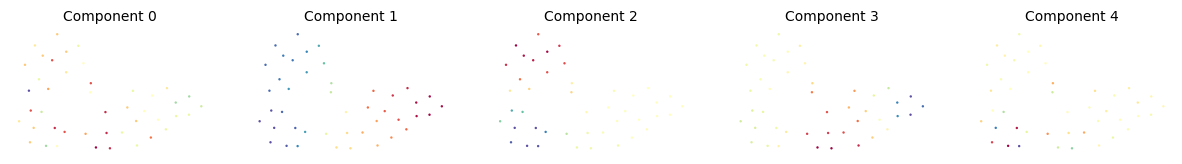

In [7]:
palantir.plot.plot_diffusion_components(pool)
plt.show()

In [8]:
# Run palantir to compute pseudotime
pr_res = palantir.core.run_palantir(pool, early_cell='15', terminal_states=['40', '13', '41', '5'], num_waypoints=100, knn=5, 
                                   eigvec_key='DM_EigenVectors')

Sampling and flocking waypoints...
Time for determining waypoints: 3.3632914225260416e-05 minutes
Determining pseudotime...
Shortest path distances using 5-nearest neighbor graph...
Time for shortest paths: 0.08196744918823243 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/palantir/core.py:500: RuntimeWarning: divide by zero encountered in divide
  aff = np.exp(-(z**2) / (adaptive_std[x] ** 2) * 0.5 - (z**2) / (adaptive_std[y] ** 2) * 0.5)


In [9]:
# Add pseudotime to adata
pool.obs['pseudotime'] = pr_res.pseudotime 

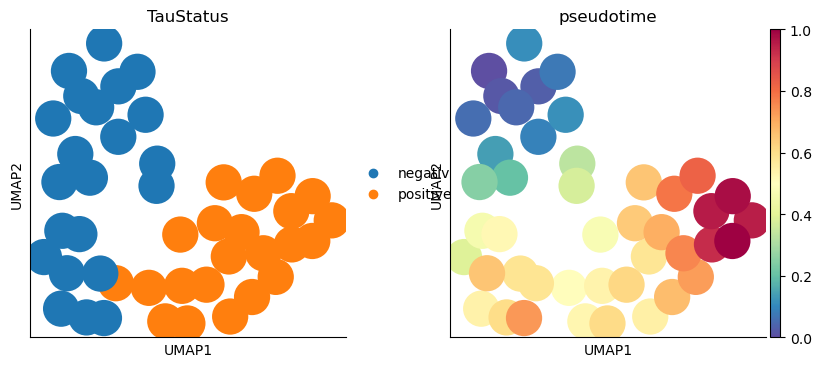

In [10]:
#Plot UMAP colored by tau status, pseudotime 
sc.pl.umap(pool, color=['TauStatus', 'pseudotime'])

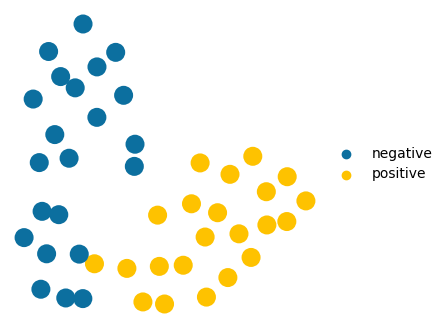

In [11]:
# Save UMAP for figure
sc.pl.umap(pool, color='TauStatus', frameon=False, size=750, title='', palette=[group_colors['neg'], group_colors['pos']], return_fig=True)
plt.savefig(os.path.join(figure_path, 'Fig2a_umap_clusters.png'), dpi=300)

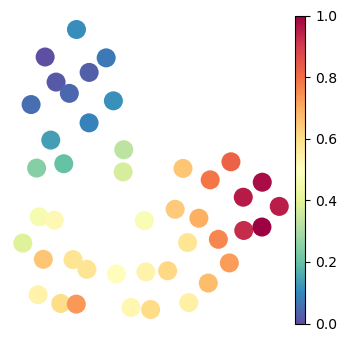

In [12]:
# Save Pseudotime UMAP for figure
sc.pl.umap(pool, color='pseudotime', frameon=False, size=750, title='', return_fig=True)
plt.savefig(os.path.join(figure_path, 'Fig2b_umap_pseudotime.png'), dpi=300)

# Correlation with pseudotime

In [13]:
pool.var['corr_stat'] = None
pool.var['corr_pval'] = None

pval_list = []

for i in tqdm(pool.var.index):

    stat, pval = pearsonr(pool[:, i].X.flatten(), pool.obs['pseudotime'])
    pool.var.loc[i, 'corr_stat'] = stat
    pool.var.loc[i, 'corr_pval'] = pval
    pval_list.append(pval)

  0%|          | 0/5853 [00:00<?, ?it/s]

In [ ]:
# FDR correction
pool.var['corr_adj.pval'] = false_discovery_control(pval_list, method='bh')

print('N significant correlations pre FDR correction:', pool.var[pool.var['corr_pval'] < 0.05].shape[0])
print('N significant correlations post FDR correction:', pool.var[pool.var['corr_adj.pval'] < fdr_thresh].shape[0])

N significant correlations pre FDR correction: 1287
N significant correlations post FDR correction: 459


In [15]:
# Export summary table for paper
pool.var[['UniprotID', 'UniprotName', 'GeneName', 'corr_stat', 'corr_pval', 'corr_adj.pval']].to_csv(os.path.join(results_path, 'SuppTable2_pooled_correlation_pseudotime.csv'))

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/matplotlib/text.py:905: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/matplotlib/text.py:762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(x))
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is depre

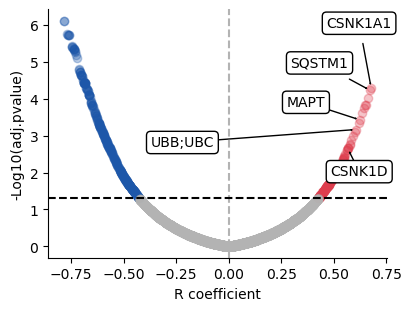

In [16]:
# Volcano plot
plt.figure(figsize=(4,3), constrained_layout=True)

plt.axvline(x=0, linestyle='dashed', color='.7')

plt.axhline(y=-np.log10(0.05), linestyle='dashed', color='k')

plt.scatter(pool.var[(pool.var['corr_adj.pval'] < 0.05) & (pool.var['corr_stat'] > 0)]['corr_stat'], 
            -np.log10(pool.var[(pool.var['corr_adj.pval'] < 0.05) & (pool.var['corr_stat'] > 0)]['corr_adj.pval']), color='#DE3E4E', alpha=.3)

plt.scatter(pool.var[(pool.var['corr_adj.pval'] < 0.05) & (pool.var['corr_stat'] < 0)]['corr_stat'], 
            -np.log10(pool.var[(pool.var['corr_adj.pval'] < 0.05) & (pool.var['corr_stat'] < 0)]['corr_adj.pval']), color='#1D57A9', alpha=.3)

plt.scatter(pool.var[pool.var['corr_adj.pval'] > 0.05]['corr_stat'], -np.log10(pool.var[pool.var['corr_adj.pval'] > 0.05]['corr_adj.pval']), color='.7', alpha=.3)

hits = ['MAPT', 'SQSTM1', 'UBB;UBC', 'CSNK1D', 'CSNK1A1']

props = dict(boxstyle='round', facecolor='white')
texts = [plt.text(pool.var[pool.var['GeneName'] == i]['corr_stat'], -np.log10(pool.var[pool.var['GeneName'] == i]['corr_adj.pval']), s=i, 
                  ha='center', va='center', bbox=props) for i in hits]

adjust_text(texts, expand=(3, 3), # expand text bounding boxes by 1.2 fold in x direction and 2 fold in y direction
             arrowprops=dict(arrowstyle='->', color='k') # ensure the labeling is clear by adding arrows
             );

plt.ylabel('-Log10(adj.pvalue)')
plt.xlabel(r'R coefficient')

plt.savefig(os.path.join(figure_path, 'Fig2c_volcano_plot.png'), dpi=300)

plt.show()

# Plot individual correlations 

## Total Tau

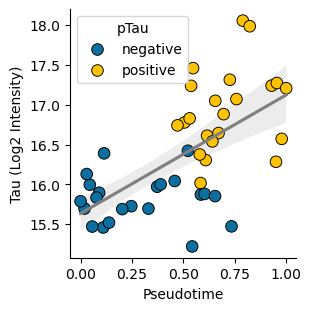

In [17]:
plt.figure(figsize=(3,3), constrained_layout=True)
sns.regplot(y=pool.X[:, pool.var['GeneName'] == 'MAPT'], x=pool.obs['pseudotime'], logistic=False, scatter=False, color='gray')
sns.scatterplot(y=pool.X[:, pool.var['GeneName'] == 'MAPT'].flatten(), x=pool.obs['pseudotime'].values, hue=pool.obs['TauStatus'].values, 
                palette=[group_colors['neg'], group_colors['pos']], s=70, edgecolor='k')
plt.ylabel('Tau (Log2 Intensity)')
plt.xlabel('Pseudotime')
plt.legend(title='pTau')
plt.savefig(os.path.join(figure_path, 'Fig2d_pseudotime_mapt.png'), dpi=300)

## pTau231

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


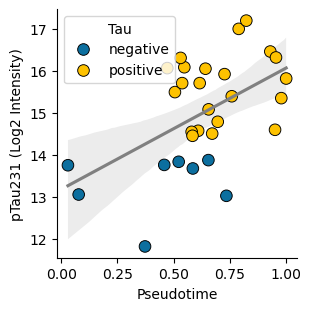

In [21]:
plt.figure(figsize=(3,3), constrained_layout=True)
sns.regplot(y=np.log2(pool.obs[pool.obs['pTau_231'] > 0]['pTau_231']), x=pool.obs[pool.obs['pTau_231'] > 0]['pseudotime'],  scatter=False, color='gray')
sns.scatterplot(y=np.log2(pool.obs['pTau_231']), x=pool.obs['pseudotime'].values, hue=pool.obs['TauStatus'].values, 
                palette=[group_colors['neg'], group_colors['pos']], s=70, edgecolor='k')
plt.ylabel('pTau231 (Log2 Intensity)')
plt.xlabel('Pseudotime')
plt.legend(title='Tau')

plt.savefig(os.path.join(figure_path, 'FigS3a_pT231_pseudotime.png'), dpi=300)
plt.show()

In [23]:
pearsonr(pool.obs['pTau_231'], pool.obs['pseudotime'])

PearsonRResult(statistic=np.float64(0.626090863093603), pvalue=np.float64(5.483074928566237e-06))

# GSEA

Pre-ranked GSEA analysis for the significantly correlated proteins

In [ ]:
hits = pool.var[pool.var['corr_adj.pval'] < fdr_thresh]
sorted_hits = hits.sort_values(by='corr_stat', ascending=False)

for i in sorted_hits.index:
    if ';' in sorted_hits.loc[i, 'GeneName']:
        sorted_hits.loc[i, 'GeneName'] = sorted_hits.loc[i, 'GeneName'].split(';')[0]

sorted_hits.index = sorted_hits['GeneName']

sorted_hits['corr_stat'] = sorted_hits['corr_stat'].astype(float)
rnk = sorted_hits['corr_stat']

In [29]:
pre_res = gp.prerank(rnk=rnk,
                     gene_sets='GO_Biological_Process_2025',
                     threads=4,
                     min_size=15,
                     max_size=1000,
                     permutation_num=1000,
                     outdir=None,
                     seed=6,
                     verbose=True,
                    )

2026-04-16 11:35:30,991 [INFO] Parsing data files for GSEA.............................
2026-04-16 11:35:30,991 [INFO] Enrichr library gene sets already downloaded in: /Users/mathieu/.cache/gseapy, use local file
2026-04-16 11:35:31,030 [INFO] 5310 gene_sets have been filtered out when max_size=1000 and min_size=15
2026-04-16 11:35:31,031 [INFO] 0033 gene_sets used for further statistical testing.....
2026-04-16 11:35:31,031 [INFO] Start to run GSEA...Might take a while..................
2026-04-16 11:35:31,072 [INFO] Congratulations. GSEApy runs successfully................



In [30]:
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[1:7],
                   show_ranking=False, # whether to show the second yaxis
                   figsize=(3,4), ofname=os.path.join(figure_path, 'FigS3b_global_enrichment.png'))

# Heatmap

In [34]:
# Order samples by pseudotime
pseudotime_idx = [int(i) for i in list(pool.obs.sort_values(by='pseudotime', ascending=True).index)]

In [35]:
# Prepare data for heatmap
data_hm = pool[pseudotime_idx, pool.var['corr_adj.pval'] < fdr_thresh].X.T
data_hm = (data_hm - data_hm.mean(axis=1, keepdims=True)) / data_hm.std(axis=1, keepdims=True)

In [38]:
# Correlation distance
dist = pdist(data_hm, metric='euclidean')

# Hierarchical clustering
Z = linkage(dist, method='ward')

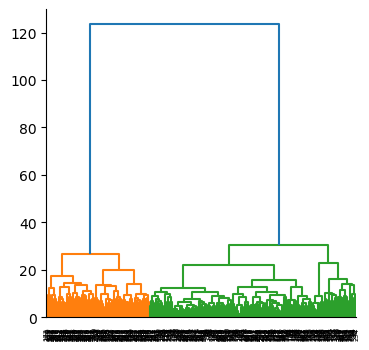

Exception ignored in: <function ResourceTracker.__del__ at 0x106591300>
Traceback (most recent call last):
  File "/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [39]:
# Plot dendrogram
dendrogram(Z)
plt.show()

In [41]:
# Define clusters
clusters = fcluster(Z, t=4, criterion='maxclust') 

# Annotate proteins with cluster
clusters_var = pool.var[pool.var['corr_adj.pval'] < fdr_thresh]
clusters_var['cluster'] = clusters
clusters_var.reset_index(inplace=True)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_23065/4125138831.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clusters_var['cluster'] = clusters


In [58]:
# Sorted metadata
pool.obs['Tau'] = list(pool[:, pool.var['GeneName'] == 'MAPT'].X.flatten())
sorted_obs = pool.obs.copy().sort_values(by='pseudotime', ascending=True)

# Log2 ptau intensities
sorted_obs['Log2pTau_217'] = np.log2(sorted_obs['pTau_217'] + 1)
sorted_obs['Log2pTau_231'] = np.log2(sorted_obs['pTau_231'] + 1)

In [60]:
# Case id blinding for figure
case_id = {
    '35/18': 1,
    '68/19': 2,
    '5/12': 3,
    '78/15': 4,
    '75/13': 5,
    '56/14': 6,
    '8/11': 7,
    '14/13': 8,
    '3/16': 9,
    '93/17': 10
}

# Map patient ID to case ID
sorted_obs['case_id'] = sorted_obs['PatientID'].map(case_id)

In [61]:
col_annot = pch.HeatmapAnnotation(
    PatientID = pch.anno_simple(sorted_obs['case_id'], cmap='tab10'),
    TauStatus = pch.anno_simple(sorted_obs['TauStatus'], colors=group_colors),
    Pseudotime = pch.anno_simple(sorted_obs['pseudotime'], cmap='plasma'), 
    TauLevels = pch.anno_simple(sorted_obs['Tau'], cmap='plasma'),
    Thr217 = pch.anno_simple(sorted_obs['Log2pTau_217'], cmap='Reds'),
    Thr231 = pch.anno_simple(sorted_obs['Log2pTau_231'], cmap='Reds'), 
    )

In [62]:
row_annot = pch.HeatmapAnnotation(
    Cluster = pch.anno_simple(clusters_var['cluster'], cmap='tab20', legend=True,height=5), 
    axis=0
)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations


/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 23.6375 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


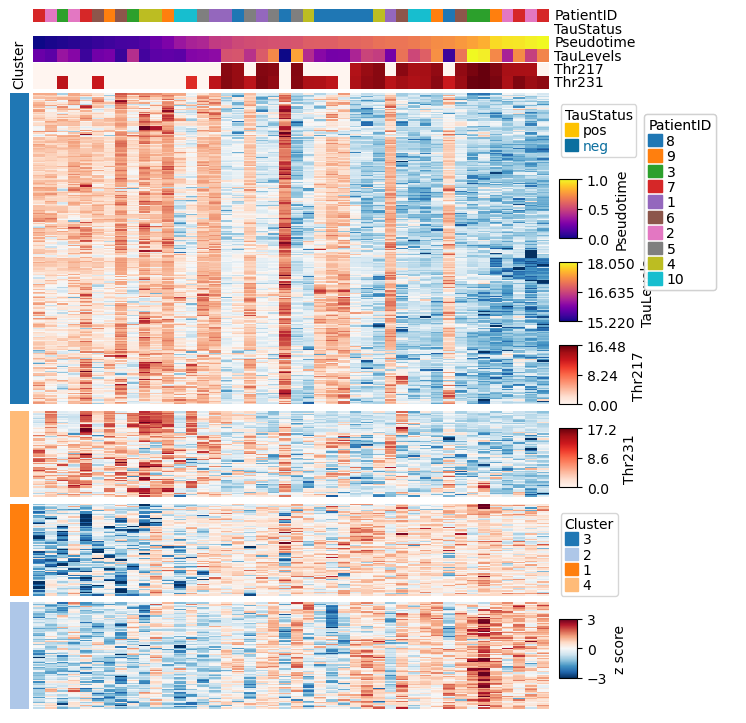

In [67]:
plt.figure(figsize=(7,8))
pch.ClusterMapPlotter(data=pd.DataFrame(pool[pseudotime_idx, pool.var['corr_adj.pval'] < fdr_thresh].X.T, columns=sorted_obs.index), 
                      z_score=0, cmap='RdBu_r', center=0, vmin=-3, vmax=3, col_cluster=False, label='z score', 
                      top_annotation=col_annot, row_cluster_metric='euclidean', row_cluster_method='ward', 
                     left_annotation=row_annot, row_split=clusters_var['cluster'], row_split_gap=1.5)

plt.savefig(os.path.join(figure_path, 'FigS3c_heatmap_pseudotime_corr.png'), dpi=300)

# Gene ontology analysis of each cluster

In [69]:
for i in clusters_var['cluster'].unique():
    enr_cluster = gp.enrichr(
    gene_list=clusters_var[clusters_var['cluster'] == i]['GeneName'],
    gene_sets=['GO_Biological_Process_2025'],  # choose your DB
    organism='human',
    outdir=None)

    enr_cluster.results.sort_values('Adjusted P-value').head()
    ax = gp.dotplot(enr_cluster.res2d, figsize=(3,5), size=10, x="Adjusted P-value", show_ring=True, ofname=os.path.join(figure_path, f'FigS3_enrichment_cluster{i}.png'))